# Road Accident Analysis

Investigate road traffic accidents to identify the factors associated with accidents and accident severity, including driver, vehicle, road, weather, lighting, time, and collision-related factors.

## 1. Load the dataset

In [100]:
import pandas as pd
import numpy as np

df = pd.read_csv('RTA_Dataset.csv')

print("Shape (rows, columns):", df.shape)
df.head()
# pd.set_option('display.max_columns', None)
# df.head()


Shape (rows, columns): (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [101]:
df.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='str')

In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Age_band_of_driver           12316 non-null  str  
 3   Sex_of_driver                12316 non-null  str  
 4   Educational_level            11575 non-null  str  
 5   Vehicle_driver_relation      11737 non-null  str  
 6   Driving_experience           11487 non-null  str  
 7   Type_of_vehicle              11366 non-null  str  
 8   Owner_of_vehicle             11834 non-null  str  
 9   Service_year_of_vehicle      8388 non-null   str  
 10  Defect_of_vehicle            7889 non-null   str  
 11  Area_accident_occured        12077 non-null  str  
 12  Lanes_or_Medians             11931 non-null  str  
 13  Road_allignment              12174 non-null  str  
 14  T

In [103]:
df.replace('na', np.nan, inplace=True)

missing_count = df.isnull().sum()
print(missing_count[missing_count > 0])

Educational_level           741
Vehicle_driver_relation     579
Driving_experience          829
Type_of_vehicle             950
Owner_of_vehicle            482
Service_year_of_vehicle    3928
Defect_of_vehicle          4427
Area_accident_occured       239
Lanes_or_Medians            385
Road_allignment             142
Types_of_Junction           887
Road_surface_type           172
Type_of_collision           155
Vehicle_movement            308
Casualty_class             4443
Sex_of_casualty            4443
Age_band_of_casualty       4443
Casualty_severity          4443
Work_of_casuality          3198
Fitness_of_casuality       2635
dtype: int64


In [104]:
df['Casualty_class'].unique()

<StringArray>
[nan, 'Driver or rider', 'Pedestrian', 'Passenger']
Length: 4, dtype: str

In [105]:
for col in ['Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity']:
    na_count = df[col].isna().sum()
    print(f"{col}: {na_count} rows ({na_count/len(df)*100:.1f}%) are missing")

Casualty_class: 4443 rows (36.1%) are missing
Sex_of_casualty: 4443 rows (36.1%) are missing
Age_band_of_casualty: 4443 rows (36.1%) are missing
Casualty_severity: 4443 rows (36.1%) are missing


In [106]:
# Replace the literal text 'na' with a proper missing value (NaN) across the whole dataframe
df.replace('na', np.nan, inplace=True)

# Recheck missing percentages now that 'na' strings are real NaNs
missing_pct = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

Sex_of_casualty            36.1
Age_band_of_casualty       36.1
Casualty_severity          36.1
Casualty_class             36.1
Defect_of_vehicle          35.9
Service_year_of_vehicle    31.9
Work_of_casuality          26.0
Fitness_of_casuality       21.4
Type_of_vehicle             7.7
Types_of_Junction           7.2
Driving_experience          6.7
Educational_level           6.0
Vehicle_driver_relation     4.7
Owner_of_vehicle            3.9
Lanes_or_Medians            3.1
Vehicle_movement            2.5
Area_accident_occured       1.9
Road_surface_type           1.4
Type_of_collision           1.3
Road_allignment             1.2
dtype: float64


In [107]:
cols_to_drop = ['Defect_of_vehicle', 'Service_year_of_vehicle',
                'Work_of_casuality', 'Fitness_of_casuality']

df.drop(columns=cols_to_drop, inplace=True)
print("Remaining columns:", df.shape[1])

Remaining columns: 28


In [108]:
fill_unknown_cols = [
    'Type_of_vehicle', 'Types_of_Junction', 'Driving_experience', 'Educational_level',
    'Vehicle_driver_relation', 'Owner_of_vehicle', 'Lanes_or_Medians', 'Vehicle_movement',
    'Area_accident_occured',
    'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity'
]

for col in fill_unknown_cols:
    df[col] = df[col].fillna('Unknown')

print("Missing values left in these columns:", df[fill_unknown_cols].isna().sum().sum())

Missing values left in these columns: 0


In [109]:
before = len(df)

df.dropna(subset=['Road_surface_type', 'Type_of_collision', 'Road_allignment'], inplace=True)

print(f"Rows before: {before}, rows after: {len(df)}  (dropped {before - len(df)} rows, "
      f"{(before-len(df))/before*100:.1f}%)")

Rows before: 12316, rows after: 11853  (dropped 463 rows, 3.8%)


In [110]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')
df['Hour'] = df['Time'].dt.hour

df[['Time', 'Hour']].head()

,Time,Hour
0,1900-01-01 17:02:00,17
1,1900-01-01 17:02:00,17
3,1900-01-01 01:06:00,1
4,1900-01-01 01:06:00,1
7,1900-01-01 17:20:00,17


In [111]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count}")

Duplicate rows found: 0


In [112]:
print("Final shape:", df.shape)
print(f"Rows kept: {len(df)} out of 12,316 original ({len(df)/12316*100:.1f}%)")
print("Total missing values remaining:", df.isna().sum().sum())

Final shape: (11853, 29)
Rows kept: 11853 out of 12,316 original (96.2%)
Total missing values remaining: 0


In [113]:
# Save the cleaned dataset for the visualization notebook
df.to_csv('RTA_Dataset_cleaned.csv', index=False)
print("Saved cleaned dataset:", df.shape)

Saved cleaned dataset: (11853, 29)


# Road Accident Analysis — Exploring Data Characteristics

In [114]:
df = pd.read_csv('RTA_Dataset_cleaned.csv')
pd.set_option('display.max_columns', None)

print("Shape:", df.shape)
df.head()

Shape: (11853, 29)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour
0,1900-01-01 17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Residential areas,Unknown,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,Unknown,Unknown,Unknown,Unknown,Not a Pedestrian,Moving Backward,Slight Injury,17
1,1900-01-01 17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,Unknown,Unknown,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,17
2,1900-01-01 01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Not a Pedestrian,Changing lane to the right,Slight Injury,1
3,1900-01-01 01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Unknown,Owner,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Unknown,Unknown,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,1
4,1900-01-01 17:20:00,Friday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Governmental,Residential areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,U-Turn,Unknown,Unknown,Unknown,Unknown,Not a Pedestrian,No priority to vehicle,Slight Injury,17


In [115]:
df['Accident_severity'].value_counts()

Accident_severity
Slight Injury     10030
Serious Injury     1670
Fatal injury        153
Name: count, dtype: int64

In [116]:
df[['Number_of_vehicles_involved', 'Number_of_casualties']].describe()

,Number_of_vehicles_involved,Number_of_casualties
count,11853.000000,11853.000000
mean,2.041508,1.550156
std,0.688950,1.007122
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [117]:
q1 = df['Number_of_casualties'].quantile(0.25)
q3 = df['Number_of_casualties'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outlier_count = (df['Number_of_casualties'] > upper_bound).sum()

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Upper bound for normal values: {upper_bound}")
print(f"Accidents above this bound (potential outliers): {outlier_count}")

Q1: 1.0, Q3: 2.0, IQR: 1.0
Upper bound for normal values: 3.5
Accidents above this bound (potential outliers): 693


In [118]:
df['Cause_of_accident'].value_counts()

Cause_of_accident
No distancing                           2188
Changing lane to the right              1730
Changing lane to the left               1410
Driving carelessly                      1363
No priority to vehicle                  1167
Moving Backward                         1086
No priority to pedestrian                693
Other                                    435
Overtaking                               417
Driving under the influence of drugs     325
Driving to the left                      277
Getting off the vehicle improperly       186
Driving at high speed                    165
Overturning                              148
Turnover                                  73
Overspeed                                 59
Overloading                               57
Drunk driving                             27
Unknown                                   24
Improper parking                          23
Name: count, dtype: int64

In [119]:
print(df['Weather_conditions'].value_counts())
print()
print(df['Light_conditions'].value_counts())

Weather_conditions
Normal               9685
Raining              1280
Other                 287
Unknown               281
Cloudy                119
Windy                  97
Snow                   58
Raining and Windy      37
Fog or mist             9
Name: count, dtype: int64

Light_conditions
Daylight                   8463
Darkness - lights lit      3164
Darkness - no lighting      186
Darkness - lights unlit      40
Name: count, dtype: int64


In [120]:
df['Hour'].value_counts().sort_index()

Hour
0      198
1      129
2       79
3       81
4       90
5       75
6      205
7      516
8      810
9      535
10     486
11     577
12     665
13     742
14     617
15     823
16     889
17    1178
18     929
19     688
20     573
21     386
22     381
23     201
Name: count, dtype: int64

# Road Accident Analysis — Visualizations & Insights

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('RTA_Dataset_cleaned.csv')
plt.rcParams['figure.figsize'] = (9, 6)

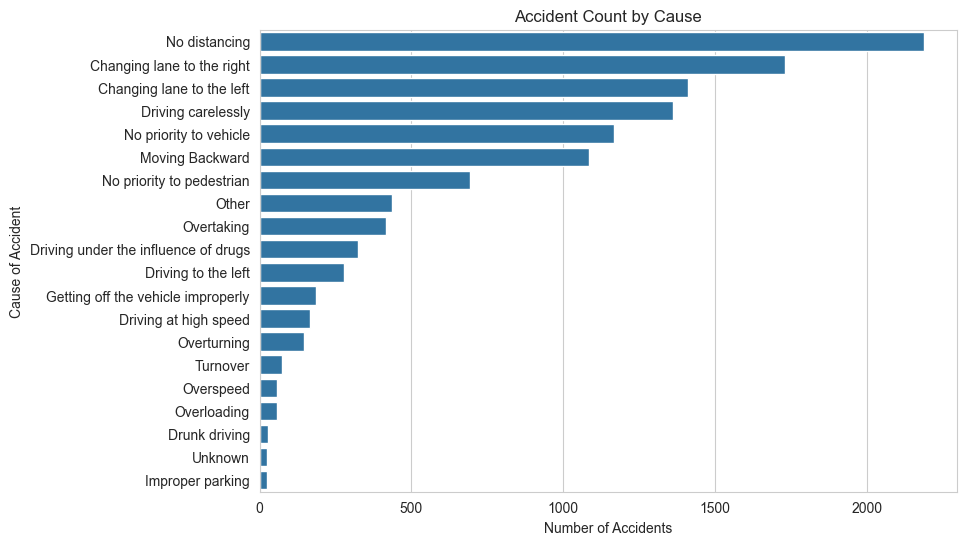

In [ ]:
order = df['Cause_of_accident'].value_counts().index

sns.countplot(data=df, y='Cause_of_accident', order=order)
plt.title('Accident Count by Cause')
plt.xlabel('Number of Accidents')
plt.ylabel('Cause of Accident')
plt.show()

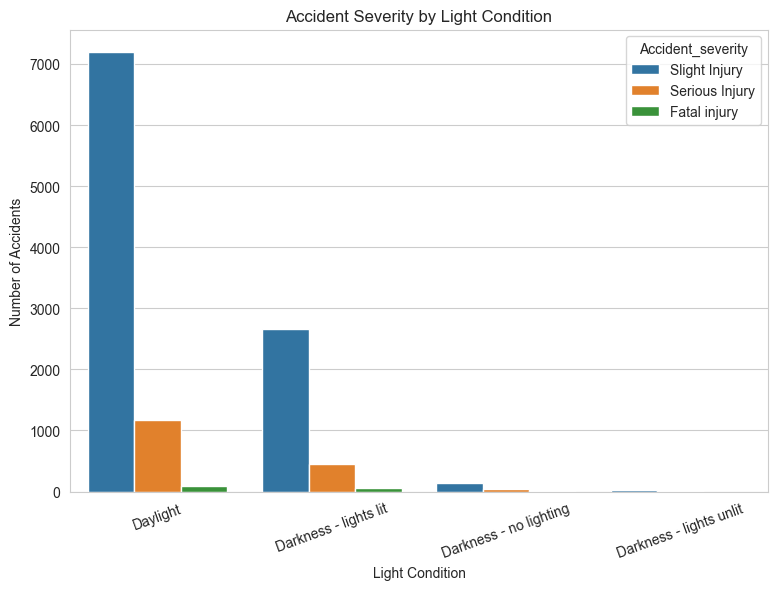

In [ ]:
sns.countplot(data=df, x='Light_conditions', hue='Accident_severity')
plt.title('Accident Severity by Light Condition')
plt.xlabel('Light Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=20)
plt.show()

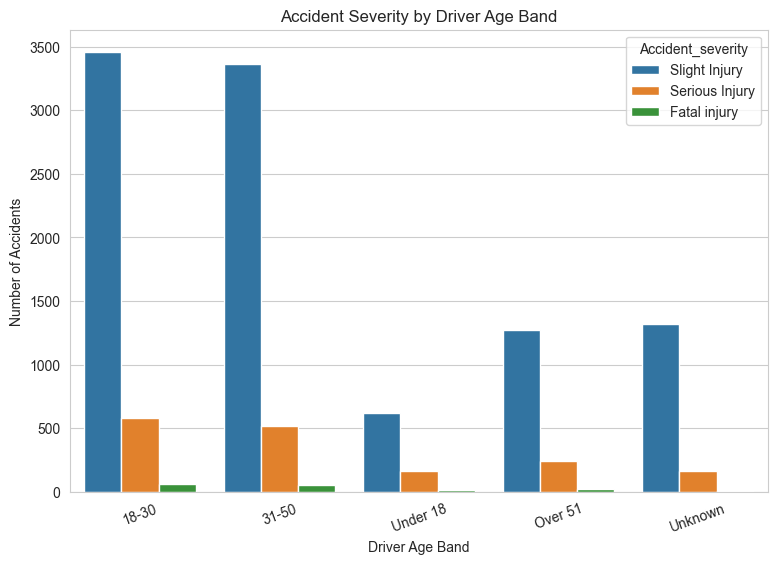

In [126]:
sns.countplot(data=df, x='Age_band_of_driver', hue='Accident_severity')
plt.title('Accident Severity by Driver Age Band')
plt.xlabel('Driver Age Band')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=20)
plt.show()

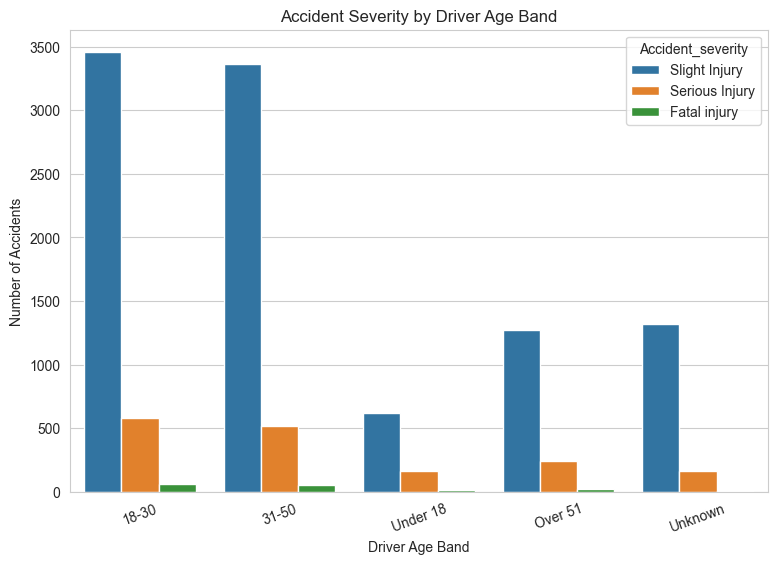

In [ ]:
sns.countplot(data=df, x='Age_band_of_driver', hue='Accident_severity')
plt.title('Accident Severity by Driver Age Band')
plt.xlabel('Driver Age Band')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=20)
plt.show()

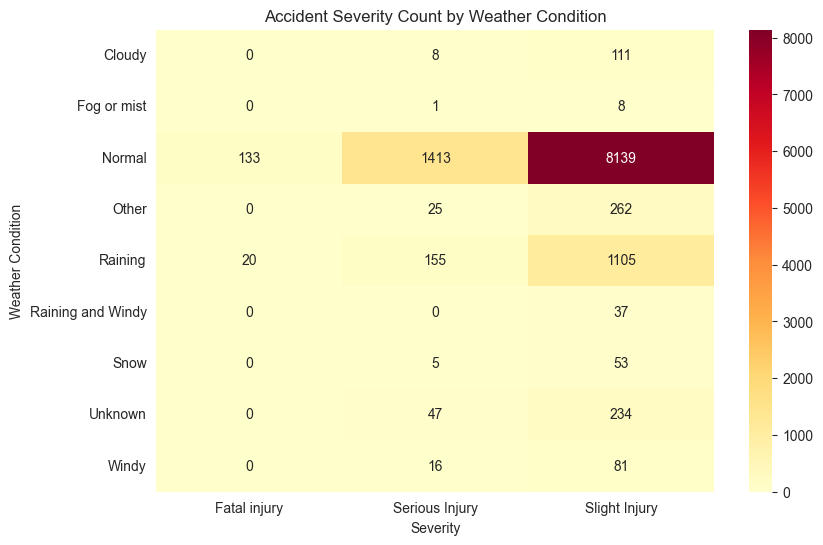

In [127]:
ct = pd.crosstab(df['Weather_conditions'], df['Accident_severity'])

sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Accident Severity Count by Weather Condition')
plt.xlabel('Severity')
plt.ylabel('Weather Condition')
plt.show()

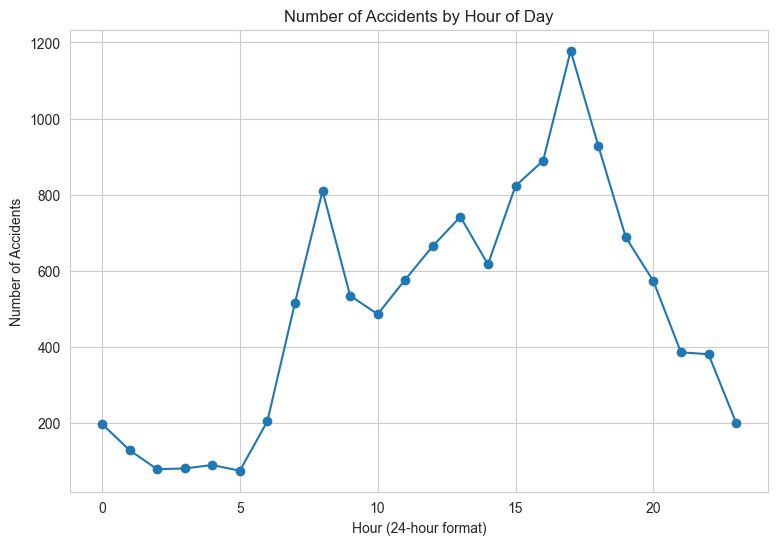

In [128]:
df['Hour'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Number of Accidents by Hour of Day')
plt.xlabel('Hour (24-hour format)')
plt.ylabel('Number of Accidents')
plt.show()

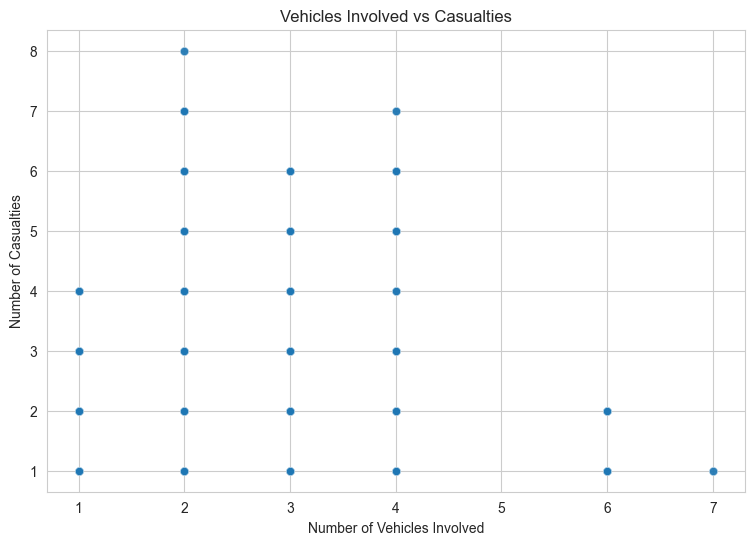

In [129]:
sns.scatterplot(data=df, x='Number_of_vehicles_involved', y='Number_of_casualties', alpha=0.3)
plt.title('Vehicles Involved vs Casualties')
plt.xlabel('Number of Vehicles Involved')
plt.ylabel('Number of Casualties')
plt.show()

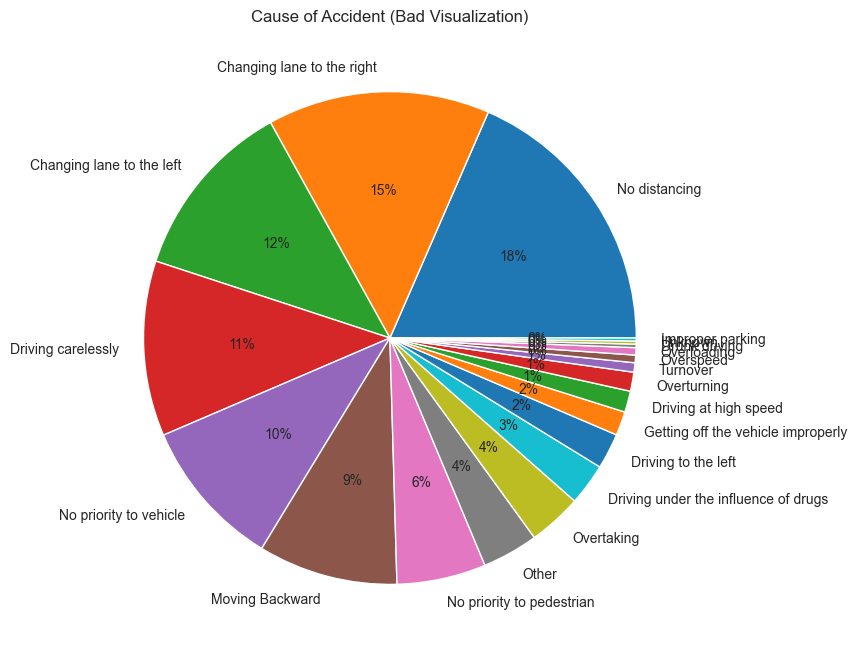

In [130]:
cause_counts = df['Cause_of_accident'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(cause_counts.values, labels=cause_counts.index, autopct='%1.0f%%')
plt.title('Cause of Accident (Bad Visualization)')
plt.show()

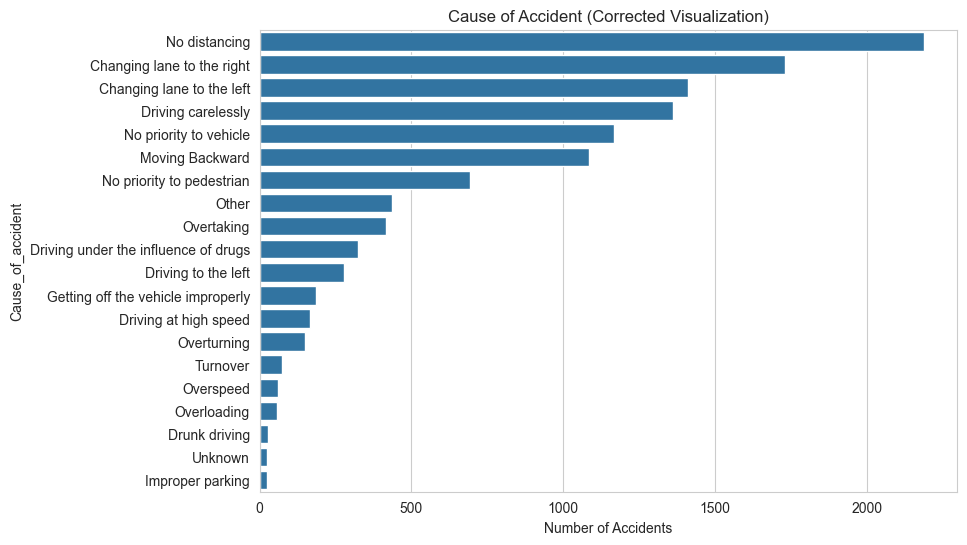

In [131]:
order = df['Cause_of_accident'].value_counts().index

sns.countplot(data=df, y='Cause_of_accident', order=order)
plt.title('Cause of Accident (Corrected Visualization)')
plt.xlabel('Number of Accidents')
plt.show()

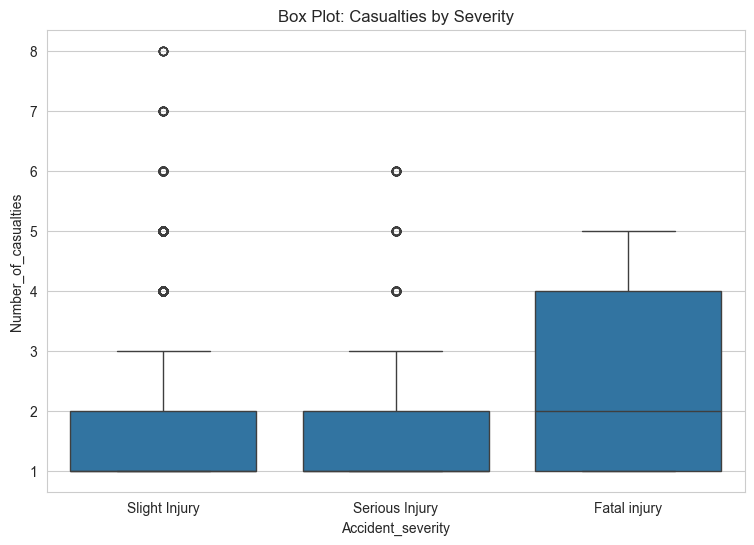

In [132]:
order_sev = ['Slight Injury', 'Serious Injury', 'Fatal injury']

sns.boxplot(data=df, x='Accident_severity', y='Number_of_casualties', order=order_sev)
plt.title('Box Plot: Casualties by Severity')
plt.show()

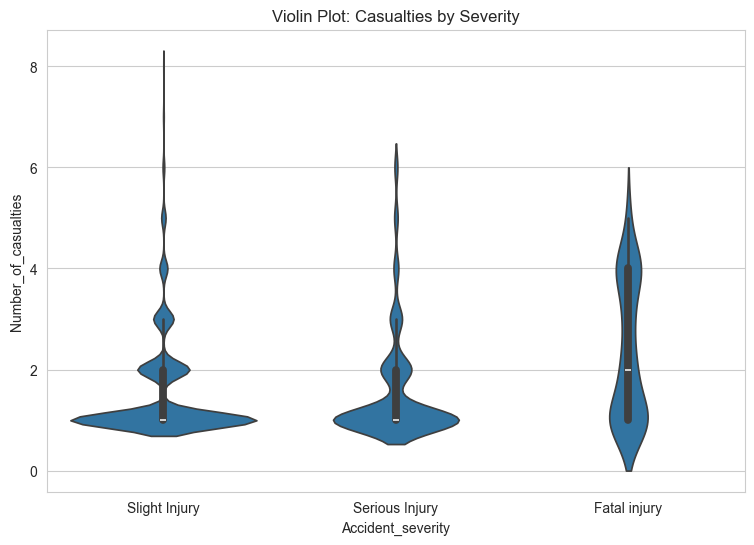

In [133]:
sns.violinplot(data=df, x='Accident_severity', y='Number_of_casualties', order=order_sev)
plt.title('Violin Plot: Casualties by Severity')
plt.show()